# Packages

In [191]:
# Basic Package Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Non-basic package imports
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.nn import CrossEntropyLoss
import requests
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# Packages I don't understand
from fcd_torch import FCD
import rdkit
from collections import Counter
import gc
import pickle
import wandb

# Add the Python_files directory to the Python path
import sys
import os
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'Python_files'))

# Now you can import your modules
import functions_enc as f
import function_depot as fd

# Functions

## Means and Standard Deviations Confusion Matrices

In [192]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.metrics import confusion_matrix
import os
from glob import glob
def create_percentage_confusion_matrix_mean_std(folder, 
                                                folder_name, 
                                                bin_size, 
                                                threshold_size, use_super_test=False, 
                                                save_plots=True, 
                                                test_in=True,
                                                train_in=False, 
                                                num_loops=None):
    """
    Compute mean and stddev of percentage confusion matrices over multiple looped output files.
    Will process multiple parquet files matching the base name pattern (before loop number).
    Plots the mean confusion matrix; each cell annotated with "mean ± std".
    Optionally limit the number of loops/files used with num_loops.
    """

    if not test_in and not train_in:
        print("No data to use, toggle train_in or test_in to True.")
        return

    def response_to_tox_class_local(response_value):
        if response_value <= 5:
            return 0
        elif response_value <= 50:
            return 1
        elif response_value <= 500:
            return 2
        elif response_value <= 5000:
            return 3
        else:
            return 4

    # Prepare the file pattern for glob
    folder_path = os.path.join(folder, folder_name)
    bin_part = str(bin_size).replace('.', '_')
    threshold_part = str(threshold_size).replace('.', '_')
    base_fp = (
        f"super_test_cond_enc_bin{bin_part}_thresh{threshold_part}_df_spectra"
        if use_super_test else f"cond_enc_bin{bin_part}_thresh{threshold_part}_df_spectra"
    )
    file_pattern = os.path.join(folder_path, f"{base_fp}_loop*.parquet")

    file_list = sorted(glob(file_pattern))
    if len(file_list) == 0:
        raise FileNotFoundError(f"No files found matching pattern: {file_pattern}")
    if num_loops is not None:
        file_list = file_list[:num_loops]

    all_cm_percent = []
    n_classes = 5
    class_labels = ["Tox Level 0", "Tox Level 1", "Tox Level 2", "Tox Level 3", "Tox Level 4"]

    for fname in file_list:
        df = pd.read_parquet(fname)
        # Filter based on train_in and test_in flags
        if 'train' in df.columns:
            if train_in and test_in:
                # Include both train and test
                pass
            elif train_in:
                # Include only train
                df = df[df['train'] == 1].copy()
            elif test_in:
                # Include only test
                df = df[df['train'] == 0].copy()
        
        df['tox_class'] = df['Response'].apply(response_to_tox_class_local)

        y_true = df['tox_class'].values
        y_pred = df['cond_tox_pred_class'].values

        cm = confusion_matrix(y_true, y_pred, labels=np.arange(n_classes))
        # Row-wise normalization (%)
        with np.errstate(divide='ignore', invalid='ignore'):
            cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
            cm_percent = np.nan_to_num(cm_percent)
        all_cm_percent.append(cm_percent)

    all_cm_percent = np.array(all_cm_percent)  # shape (n_files, n_classes, n_classes)
    mean_cm = np.mean(all_cm_percent, axis=0)
    std_cm = np.std(all_cm_percent, axis=0)

    # Plotting
    plt.figure(figsize=(10, 8))
    annot = np.empty_like(mean_cm, dtype=object)
    for i in range(n_classes):
        for j in range(n_classes):
            annot[i, j] = f"{mean_cm[i, j]:.1f}±{std_cm[i, j]:.1f}"

    sns.heatmap(
        mean_cm, annot=annot, fmt='', cmap='Blues',
        xticklabels=class_labels, yticklabels=class_labels,
        cbar_kws={'label': 'Mean Percentage (%)'},
        square=True
    )

    test_type = "Super Test" if use_super_test else "Regular Test"
    # Build data label based on train_in and test_in
    if train_in and test_in:
        data_label = " (Train + Test)"
    elif train_in:
        data_label = " (Train Only)"
    elif test_in:
        data_label = " (Test Only)"
    else:
        data_label = ""
    
    plt.title(f"Confusion Matrix (Mean±Std%) - {test_type}{data_label} (Bin={bin_size}, Threshold={threshold_size})\nn={len(file_list)} loops")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()

    if save_plots:
        save_path = os.path.join(folder_path, f"confusion_matrix_percentages_meanstd_{'super_test_' if use_super_test else ''}bin{bin_size}_thr{threshold_size}_loops.png")
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved as: {save_path}")

    plt.show()

## Direct Prediction Model Confusion Matrix

In [193]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os
from glob import glob

def create_confusion_matrix_general_mean_std(
    folder_path,
    bin_val,
    threshold_val,
    pred_class_col='cond_tox_pred_class',
    response_col='Response',
    train_col='train',
    file_prefix='cond_enc',
    use_super_test=False,
    test_in=True,
    train_in=False,
    save_plots=False,
    figsize=(10, 8),
    num_loops=None  # New argument to limit number of loops/files
):
    if not test_in and not train_in:
        print("No data to use, toggle train_in or test_in to True.")
        return

    bin_part = str(bin_val).replace('.', '_')
    threshold_part = str(threshold_val).replace('.', '_')
    if use_super_test:
        base_fp = f"super_test_{file_prefix}_bin{bin_part}_thresh{threshold_part}_df_spectra"
    else:
        base_fp = f"{file_prefix}_bin{bin_part}_thresh{threshold_part}_df_spectra"
    file_pattern = os.path.join(folder_path, f"{base_fp}_loop*.parquet")
    file_list = sorted(glob(file_pattern))
    if not file_list:
        raise FileNotFoundError(f"No files found matching pattern: {file_pattern}")
    if num_loops is not None:
        file_list = file_list[:num_loops]
    n_classes = 5
    class_labels = ["Tox Level 0", "Tox Level 1", "Tox Level 2", "Tox Level 3", "Tox Level 4"]

    all_cm_percent = []

    for fname in file_list:
        df = pd.read_parquet(fname)
        if train_col in df.columns:
            # Filter based on train_in and test_in flags
            if train_in and test_in:
                # Include both train and test
                pass
            elif train_in:
                # Include only train
                df = df[df[train_col] == 1].copy()
            elif test_in:
                # Include only test
                df = df[df[train_col] == 0].copy()
        
        def response_to_tox_class(response_value):
            if response_value <= 5:
                return 0
            elif response_value <= 50:
                return 1
            elif response_value <= 500:
                return 2
            elif response_value <= 5000:
                return 3
            else:
                return 4
        df['tox_class'] = df[response_col].apply(response_to_tox_class)
        y_true = df['tox_class'].values
        y_pred = df[pred_class_col].values
        cm = confusion_matrix(y_true, y_pred, labels=np.arange(n_classes))
        with np.errstate(divide='ignore', invalid='ignore'):
            cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
            cm_percent = np.nan_to_num(cm_percent)
        all_cm_percent.append(cm_percent)

    all_cm_percent = np.array(all_cm_percent)
    mean_cm = np.mean(all_cm_percent, axis=0)
    std_cm = np.std(all_cm_percent, axis=0)

    plt.figure(figsize=figsize)
    annot = np.empty_like(mean_cm, dtype=object)
    for i in range(n_classes):
        for j in range(n_classes):
            annot[i, j] = f"{mean_cm[i, j]:.1f}±{std_cm[i, j]:.1f}"

    sns.heatmap(
        mean_cm, annot=annot, fmt='', cmap='Blues',
        xticklabels=class_labels, yticklabels=class_labels,
        cbar_kws={'label': 'Mean Percentage (%)'},
        square=True
    )

    test_type = "Super Test" if use_super_test else "Regular Test"
    # Build data label based on train_in and test_in
    if train_in and test_in:
        data_label = " (Train + Test)"
    elif train_in:
        data_label = " (Train Only)"
    elif test_in:
        data_label = " (Test Only)"
    else:
        data_label = ""
    
    plt.title(f"Confusion Matrix (Mean±Std%) - {test_type}{data_label}\n(Bin={bin_val}, Threshold={threshold_val})\nn={len(file_list)} loops")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()

    if save_plots:
        save_path = os.path.join(folder_path, f"confusion_matrix_percentages_meanstd_{'super_test_' if use_super_test else ''}bin{bin_val}_thr{threshold_val}_loops.png")
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved as: {save_path}")

    plt.show()

## Random Forest Confusion Matrix Means and Standard Deviations

In [194]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os
from glob import glob

def create_confusion_matrix_rf_mean_std(
    folder_path,
    bin_val,
    threshold_val,
    pred_class_col='rf_predicted_tox_class',
    true_class_col='true_tox_class',
    train_col='train',
    file_prefix='rf',
    use_super_test=False,
    test_in=True,
    train_in=False,
    save_plots=False,
    figsize=(10, 8),
    num_loops=None  # New argument to limit number of loops/files
):
    """
    Create confusion matrix visualization for Random Forest classification results.
    
    Parameters:
    -----------
    folder_path : str
        Path to folder containing the parquet files
    bin_val : float
        Bin size value (e.g., 0.1, 1)
    threshold_val : float
        Threshold value (e.g., 0.05, 0.5)
    pred_class_col : str
        Column name for predicted class (default: 'rf_predicted_tox_class')
    true_class_col : str
        Column name for true class (default: 'true_tox_class')
    train_col : str
        Column name for train indicator (default: 'train')
    file_prefix : str
        Prefix for file matching (default: 'rf')
    use_super_test : bool
        If True, look for super_test files
    test_in : bool
        Include test set data
    train_in : bool
        Include train set data
    save_plots : bool
        Save the plot to file
    figsize : tuple
        Figure size
    num_loops : int or None
        Limit number of files to process
    """
    if not test_in and not train_in:
        print("No data to use, toggle train_in or test_in to True.")
        return

    bin_part = str(bin_val).replace('.', '_')
    threshold_part = str(threshold_val).replace('.', '_')
    if use_super_test:
        base_fp = f"super_test_{file_prefix}_bin{bin_part}_thresh{threshold_part}_df_spectra"
    else:
        base_fp = f"{file_prefix}_bin{bin_part}_thresh{threshold_part}_df_spectra"
    file_pattern = os.path.join(folder_path, f"{base_fp}_loop*.parquet")
    file_list = sorted(glob(file_pattern))
    if not file_list:
        raise FileNotFoundError(f"No files found matching pattern: {file_pattern}")
    if num_loops is not None:
        file_list = file_list[:num_loops]
    
    n_classes = 5
    class_labels = ["Tox Level 0", "Tox Level 1", "Tox Level 2", "Tox Level 3", "Tox Level 4"]

    all_cm_percent = []

    for fname in file_list:
        df = pd.read_parquet(fname)
        if train_col in df.columns:
            # Filter based on train_in and test_in flags
            if train_in and test_in:
                # Include both train and test
                pass
            elif train_in:
                # Include only train
                df = df[df[train_col] == 1].copy()
            elif test_in:
                # Include only test
                df = df[df[train_col] == 0].copy()
        
        # Use the true_class column directly (already computed in RF output)
        y_true = df[true_class_col].values
        y_pred = df[pred_class_col].values
        cm = confusion_matrix(y_true, y_pred, labels=np.arange(n_classes))
        with np.errstate(divide='ignore', invalid='ignore'):
            cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
            cm_percent = np.nan_to_num(cm_percent)
        all_cm_percent.append(cm_percent)

    all_cm_percent = np.array(all_cm_percent)
    mean_cm = np.mean(all_cm_percent, axis=0)
    std_cm = np.std(all_cm_percent, axis=0)

    plt.figure(figsize=figsize)
    annot = np.empty_like(mean_cm, dtype=object)
    for i in range(n_classes):
        for j in range(n_classes):
            annot[i, j] = f"{mean_cm[i, j]:.1f}±{std_cm[i, j]:.1f}"

    sns.heatmap(
        mean_cm, annot=annot, fmt='', cmap='Blues',
        xticklabels=class_labels, yticklabels=class_labels,
        cbar_kws={'label': 'Mean Percentage (%)'},
        square=True
    )

    test_type = "Super Test" if use_super_test else "Regular Test"
    # Build data label based on train_in and test_in
    if train_in and test_in:
        data_label = " (Train + Test)"
    elif train_in:
        data_label = " (Train Only)"
    elif test_in:
        data_label = " (Test Only)"
    else:
        data_label = ""
    
    plt.title(f"Random Forest Confusion Matrix (Mean±Std%) - {test_type}{data_label}\n(Bin={bin_val}, Threshold={threshold_val})\nn={len(file_list)} loops")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()

    if save_plots:
        save_path = os.path.join(folder_path, f"rf_confusion_matrix_percentages_meanstd_{'super_test_' if use_super_test else ''}bin{bin_val}_thr{threshold_val}_loops.png")
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved as: {save_path}")

    plt.show()

# Visualization Executions

## 2 Step Algorithm Visualizations

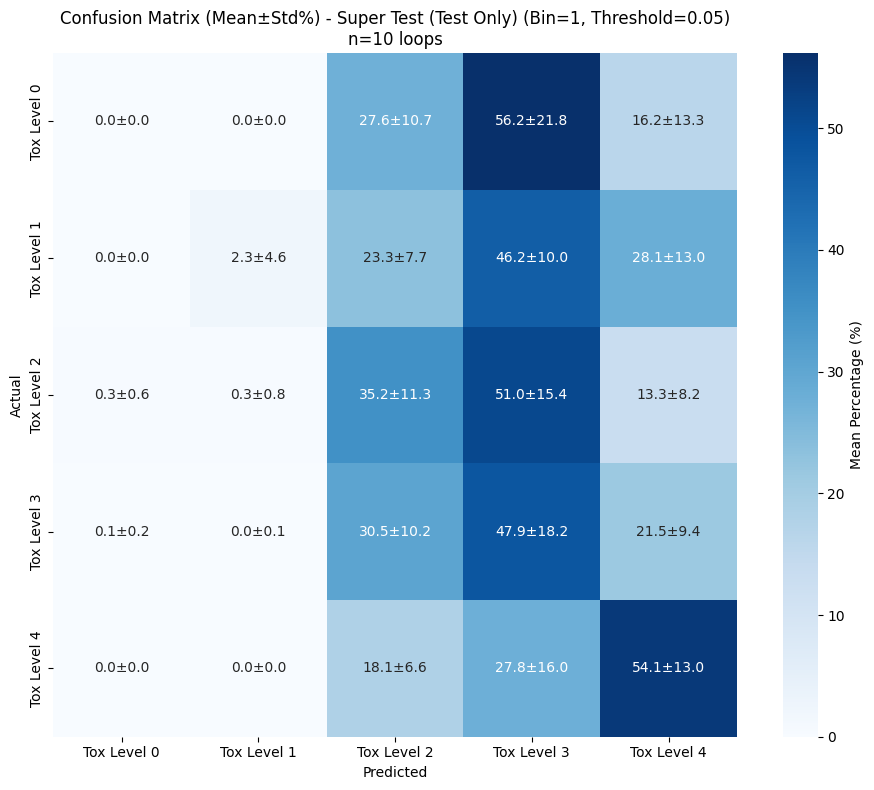

In [204]:
# Regular Confusion Matrix
create_percentage_confusion_matrix_mean_std(folder='/home/dlipsey/MITLincolnLabs/MIT_LL_data/', 
                                            folder_name='2step_cond_enc_134_loop_super_test', 
                                            bin_size=1, threshold_size=0.05, 
                                            use_super_test=True, 
                                            save_plots=False, 
                                            test_in=True,
                                            train_in=False, 
                                            num_loops=10)

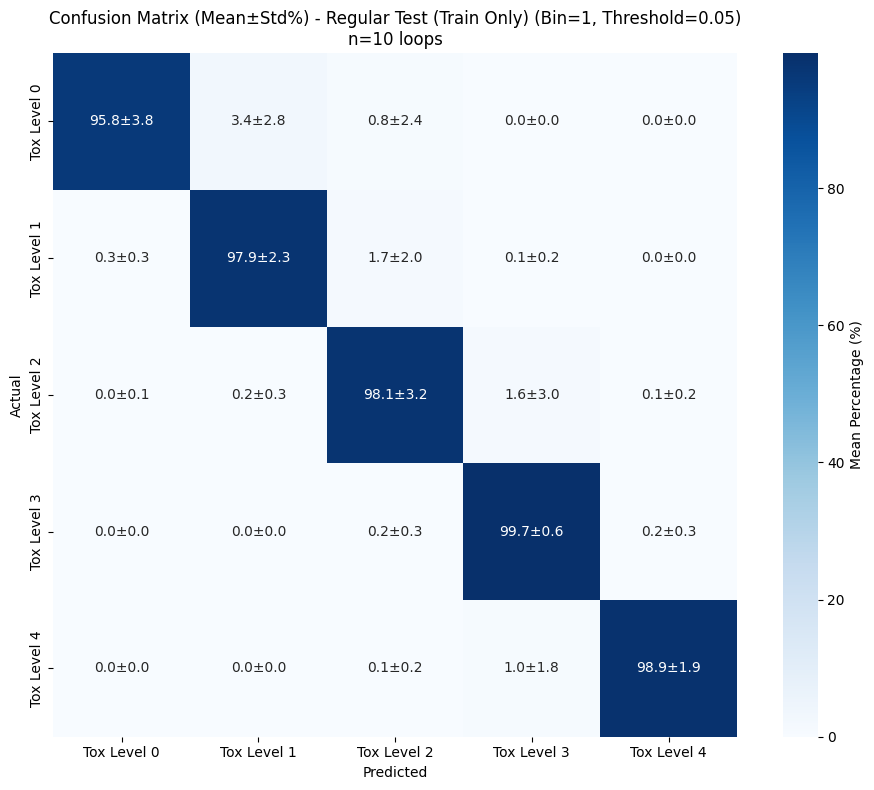

In [207]:
# Synthetic Ablation Confusion Matrix 
create_percentage_confusion_matrix_mean_std(folder='/home/dlipsey/MITLincolnLabs/MIT_LL_data/', 
                                            folder_name='2step_synth_abl_134_loop', 
                                            bin_size=1, threshold_size=0.05, 
                                            use_super_test=False, 
                                            save_plots=False, 
                                            test_in=False,
                                            train_in=True, 
                                            num_loops=10)

## Old Train Test Split

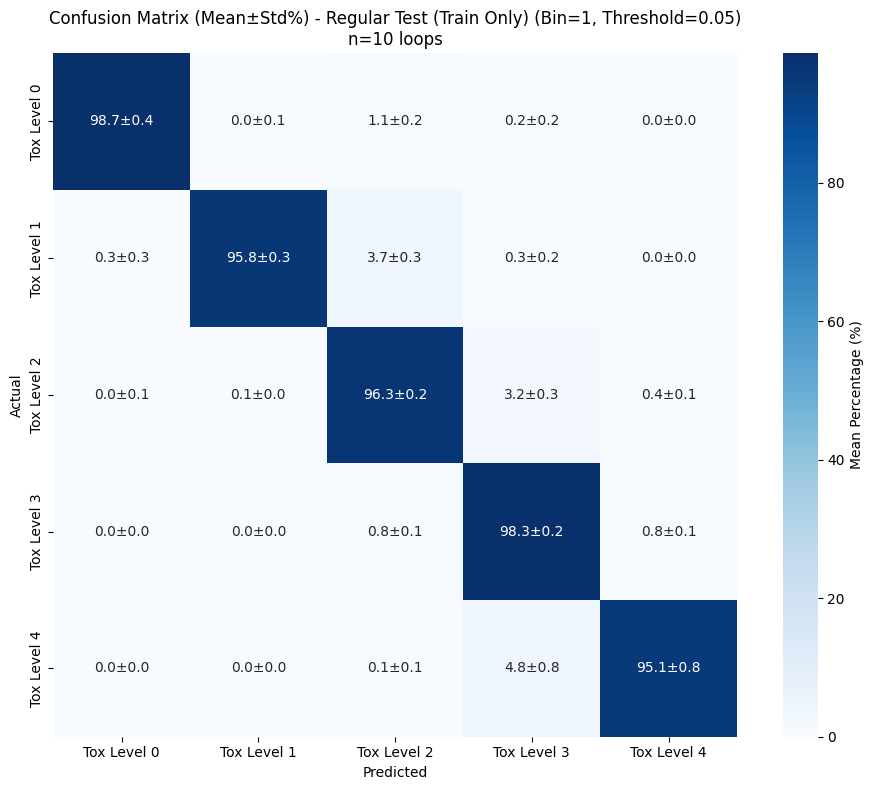

In [210]:
# Regular Confusion Matrix
create_percentage_confusion_matrix_mean_std(folder='/home/dlipsey/MITLincolnLabs/MIT_LL_data/', 
                                            folder_name='2_step_oldTTsplit_loop', 
                                            bin_size=1, threshold_size=0.05, 
                                            use_super_test=False, 
                                            save_plots=False, 
                                            test_in=False,
                                            train_in=True, 
                                            num_loops=10)

## Direct Algorithm Visualizations

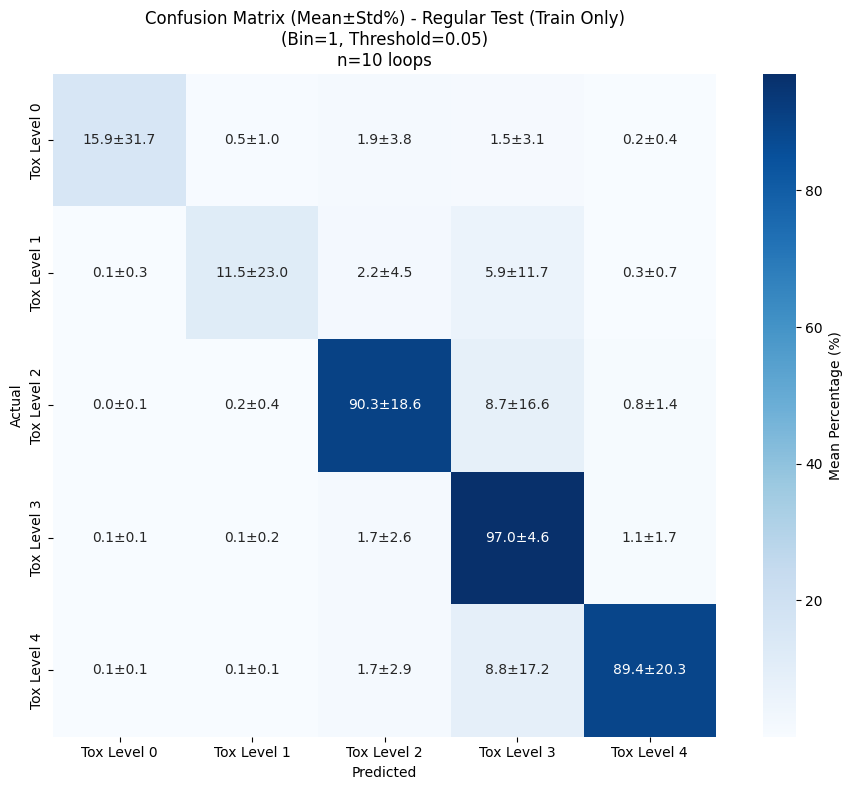

In [213]:
# Direct Prediction Regular Confusion Matrix
create_confusion_matrix_general_mean_std(
    folder_path='/home/dlipsey/MITLincolnLabs/MIT_LL_data/regular_classifier_loop',
    bin_val=1,  
    threshold_val=0.05,
    pred_class_col='direct_tox_pred_class',
    response_col='Response',
    train_col='train',
    file_prefix='direct_tox',
    use_super_test=False,
    test_in=False,
    train_in=True,
    save_plots=False,
    num_loops=10) # None for all

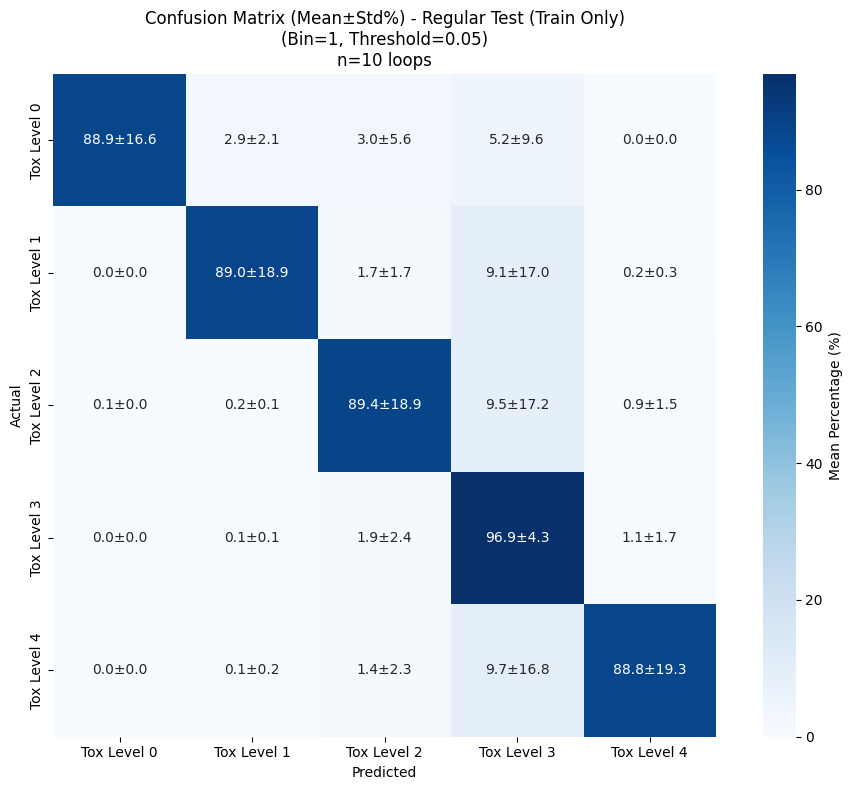

In [216]:
# Synthetic Ablation Direct Prediction Confusion Matrix
create_confusion_matrix_general_mean_std(
    folder_path='/home/dlipsey/MITLincolnLabs/MIT_LL_data/regular_classifier_synth_abl_loop',
    bin_val=1,
    threshold_val=0.05,
    pred_class_col='direct_tox_pred_class',
    response_col='Response',
    train_col='train',
    file_prefix='direct_tox',
    use_super_test=False,
    test_in=False,
    train_in=True,
    save_plots=False,
    num_loops=10) # None for all

## Random Forest Classifier Visualizations

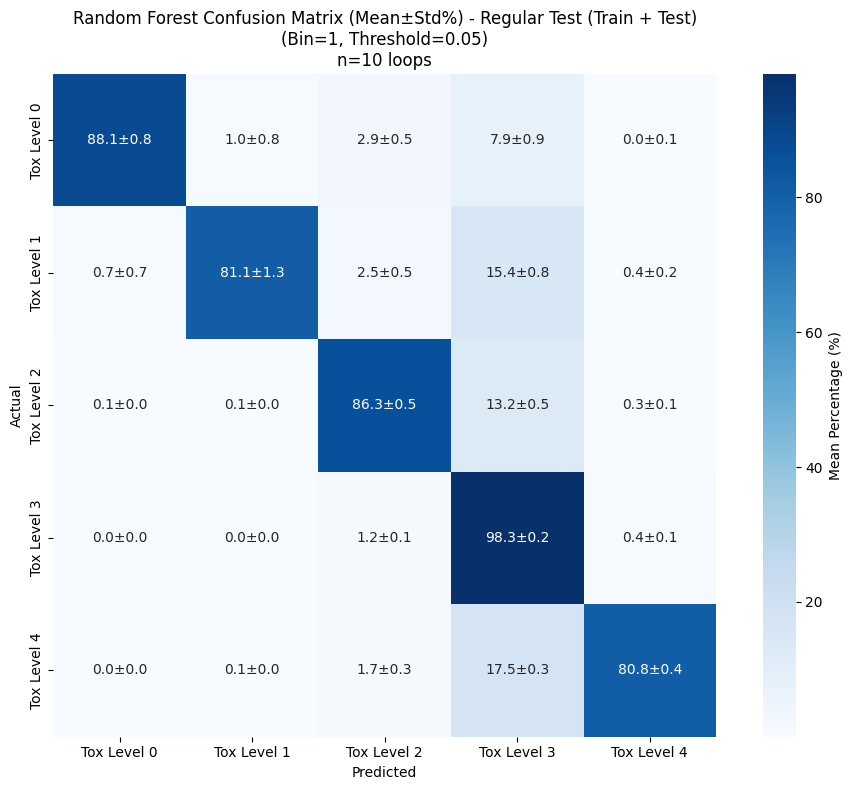

In [200]:
create_confusion_matrix_rf_mean_std(
    folder_path='/home/dlipsey/MITLincolnLabs/MIT_LL_data/rf_classifier_loop',
    bin_val=1,
    threshold_val=0.05,
    pred_class_col='rf_predicted_tox_class',      
    true_class_col='true_tox_class',              
    train_col='train',                             
    file_prefix='rf',                              
    use_super_test=False,                          
    test_in=True,                                  
    train_in=True,                                
    save_plots=False,                             
    num_loops=10                                
)

In [201]:
import pandas as pd
import function_depot as fd

# Define super test SMILES to exclude
super_test_smiles = [
    'CCOP(=S)(OCC)Oc1ccc([N+](=O)[O-])cc1',
    'CCOP(=S)(OCC)Oc1ccc(S(C)=O)cc1',
    'CC1(C)O[C@@H]2C[C@H]3[C@@H]4C[C@H](F)C5=CC(=O)C=C[C@]5(C)[C@H]4[C@@H](O)C[C@]3(C)[C@]2(C(=O)CO)O1 CC(=O)OC1(C)CC(C)C(=O)C(C(O)CC2CC(=O)NC(=O)C2)C1',
    'NC(=S)Nc1ccccc1',
    'CC(=O)OC[C@]12C[C@H](OC(=O)CC(C)C)C(C)=C[C@H]1O[C@@H]1[C@H](O)[C@@H](OC(C)=O)[C@@]2(C)[C@]12CO2',
    'CC(C)OC(=O)CCCC=CCC1C(O)CC(O)C1CCC(O)CCc1ccccc1',
    'Cc1cc(C(C)(C)C)c(O)c(C)c1CC1=NCCN1.Cl',
    'CCOP(=O)(OCC)Oc1ccc([N+](=O)[O-])cc1',
    'CCN1CC2(COC)C(OC(C)=O)CC(OC)C34C5CC6(O)C(OC)C(O)C(OC(C)=O)(C5C6OC(=O)c5ccccc5)C(C(OC)C23)C14',
    'CCOP(=O)(OCC)OC(=CCl)c1ccc(Cl)cc1Cl',
    'CCC(=O)N(c1ccccc1)C1CCN(CCc2ccccc2)CC1',
    'CNC(=O)Oc1ccccc1C1OCCO1',
    'O=C1C=C2C(=CCOC2O)O1',
    'CC(=O)C1=C(O)[C@@H]2[C@H]3c4c[nH]c5cccc(c45)C[C@H]3C(C)(C)N2C1=O',
    'Cc1cc(OC(=O)N(C)C)nn1C(=O)N(C)C',
    'C[C@@H]1Cc2c(Cl)cc(C(=O)N[C@@H](Cc3ccccc3)C(=O)O)c(O)c2C(=O)O1',
    'CNC(=O)Oc1cccc2c1OC(C)(C)O2',
    'CC(N)Cc1ccccc1',
    'CC1OC(OC2C(O)CC(OC3C(O)CC(OC4CCC5(C)C(CCC6C5CCC5(C)C(C7=CC(=O)OC7)CCC65O)C4)OC3C)OC2C)CC(O)C1O',
    'CC(=O)C1(O)Cc2c(O)c3c(c(O)c2C(OC2CC(N)C(O)C(C)O2)C1)C(=O)c1ccccc1C3=O',
    'CN1C(C(=O)Nc2ccccn2)=C(O)c2sc(Cl)cc2S1(=O)=O',
    'C=C1CCC(O)CC1=CC=C1CCCC2(C)C1CCC2C(C)C=CC(C)C(C)C',
    'CC(=O)OCC(=O)[C@@]12OC(C)(C)O[C@@H]1C[C@H]1[C@@H]3C[C@H](F)C4=CC(=O)C=C[C@]4(C)[C@@]3(F)[C@@H](O)C[C@@]12C',
    'C[C@H]1O[C@@H](O[C@H]2[C@@H](O)C[C@H](O[C@H]3[C@@H](O)C[C@H](O[C@H]4CC[C@@]5(C)[C@H](CC[C@@H]6[C@@H]5CC[C@]5(C)[C@@H](C7=CC(=O)OC7)CC[C@]65O)C4)O[C@@H]3C)O[C@@H]2C)C[C@H](O)[C@@H]1O',
    'COP(=S)(OC)Oc1ccc(S(=O)(=O)N(C)C)cc1',
    'COP(=S)(OC)SCN1C(=O)c2ccccc2C1=O',
    'CCOC(=O)C1(c2ccccc2)CCN(C)CC1',
    'CCOP(=S)(OCC)Oc1ccc2c(C)c(Cl)c(=O)oc2c1',
    'CC(C(=O)O)c1cccc(C(=O)c2ccccc2)c1',
    'S=c1[nH]c2ccccc2s1',
    'CC(=O)N1CCN(c2ccc(OC[C@H]3CO[C@](Cn4ccnc4)(c4ccc(Cl)cc4Cl)O3)cc2)CC1',
    'CN(N=O)c1ccccc1',
    'CN1C(=O)CN=C(c2ccccc2)c2cc(Cl)ccc21',
    'COc1cc2ccc(=O)oc2cc1OC',
    'CN1CCCC(n2nc(Cc3ccc(Cl)cc3)c3ccccc3c2=O)CC1',
    'CNC[C@H](O)c1cccc(O)c1',
    'C1ccc2ncccc2c1',
    'CN1C(=O)CN=C(c2ccccc2F)c2cc([N+](=O)[O-])ccc21',
    'Cn1cnc([N+](=O)[O-])c1Sc1ncnc2nc[nH]c12',
    'C=CCOC(Cn1ccnc1)c1ccc(Cl)cc1Cl',
    'COc1ccnc(CS(=O)c2nc3ccc(OC(F)F)cc3[nH]2)c1OC',
    'CCC(=O)Nc1ccc(Cl)c(Cl)c1',
    'C1CCN2C[C@@H]3C[C@@H](CN4CCCC[C@@H]34)[C@H]2C1',
    'CC(=O)CCCCn1c(=O)c2c(ncn2C)n(C)c1=O',
    'COc1ccc(N)cc1',
    'Cc1ccc(C(C)C)cc2c(C)ccc1-2',
    'Clc1ccc(C2(Cn3cncn3)CC(Br)CO2)c(Cl)c1',
    'CC(CCc1ccccc1)NCC(O)c1ccc(O)c(C(N)=O)c1',
    'CC1COC(Cn2cncn2)(c2ccc(Oc3ccc(Cl)cc3)cc2Cl)O1',
    'Cc1ccc(S(N)(=O)=O)cc1',
    'Cc1cc(=O)nc(C(C)C)[nH]1',
    'N[C@@H](CC(=O)N1CCn2c(nnc2C(F)(F)F)C1)Cc1cc(F)c(F)cc1F',
    'COc1cc(C=CC(=O)CC(=O)C=Cc2ccc(O)c(OC)c2)ccc1O',
    'Cc1cc(C)nc(Nc2ccccc2)n1',
    'COC(=O)Nc1nc2ccccc2[nH]1',
    'CCOC(=O)NCCOc1ccc(Oc2ccccc2)cc1',
    'COc1cc2ccc(=O)oc2cc1O',
    'Cc1ncc(COP(=O)(O)O)c(C=O)c1O',
    'OCCN(CCO)CCO',
    'O=C(O)c1cccnc1',
    'C[C@@H]1CC[C@@]2(OC1)O[C@H]1C[C@H]3[C@@H]4CC=C5C[C@@H](O)CC[C@]5(C)[C@H]4CC[C@]3(C)[C@H]1[C@@H]2C',
    'Oc1cc(O)c2c(c1)O[C@H](c1ccc(O)c(O)c1)[C@@H](O)C2',
    'O=c1[nH]c2c(c(=O)n1C1CCCCC1)CCC2',
    'NC(CCC(=O)O)C(=O)O',
    'N[C@@H](Cc1cnc[nH]1)C(=O)O',
    'COc1ccc(Cl)cc1C(=O)NCCc1ccc(S(=O)(=O)NC(=O)NC2CCCCC2)cc1',
    'CCCCC(CC)COC(=O)c1ccccc1C(=O)OCC(CC)CCCC',
    'CCCCOC(=O)CC(CC(=O)OCCCC)(OC(C)=O)C(=O)OCCC',
    'c1ccc(Nc2ccc3ccccc3c2)cc1'
]

# Load the specific dataset
dataset = pd.read_parquet("/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_spectra_meta.parquet")

# Filter out super test SMILES
print(f"Original dataset size: {len(dataset)} spectra")
dataset_filtered = dataset[~dataset['SMILES_spectra'].isin(super_test_smiles)].copy()
print(f"After removing super test SMILES: {len(dataset_filtered)} spectra")
print(f"Removed: {len(dataset) - len(dataset_filtered)} spectra\n")

# Assign toxicity levels
dataset_filtered['tox_level'] = dataset_filtered['Response'].apply(fd.assign_tox_level)

# Count unique SMILES per toxicity level
unique_smiles_counts = dataset_filtered.groupby('tox_level')['SMILES_spectra'].nunique()

# Count total spectra per toxicity level
spectra_counts = dataset_filtered['tox_level'].value_counts().sort_index()

# Create summary dataframe
summary = pd.DataFrame({
    'Toxicity Level': range(5),
    'Unique SMILES': [unique_smiles_counts.get(i, 0) for i in range(5)],
    'Total Spectra': [spectra_counts.get(i, 0) for i in range(5)]
})

print("="*80)
print("TOXICITY DISTRIBUTION (AFTER REMOVING SUPER TEST SMILES)")
print("="*80)
print(summary)

Original dataset size: 15869 spectra
After removing super test SMILES: 14853 spectra
Removed: 1016 spectra

TOXICITY DISTRIBUTION (AFTER REMOVING SUPER TEST SMILES)
   Toxicity Level  Unique SMILES  Total Spectra
0               0             32            301
1               1             47            470
2               2            283           3488
3               3            799           8302
4               4            196           2292
